In [391]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [392]:
waste = pd.read_csv('waste_classification.csv')

In [393]:
waste.info()

<class 'pandas.DataFrame'>
RangeIndex: 22564 entries, 0 to 22563
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      22564 non-null  float64
 1   f2      22564 non-null  float64
 2   f3      22564 non-null  float64
 3   f4      22564 non-null  float64
 4   f5      22564 non-null  float64
 5   f6      22564 non-null  float64
 6   f7      22564 non-null  float64
 7   f8      22564 non-null  float64
 8   f9      22564 non-null  float64
 9   f10     22564 non-null  float64
 10  f11     22564 non-null  float64
 11  f12     22564 non-null  float64
 12  f13     22564 non-null  float64
 13  f14     22564 non-null  float64
 14  f15     22564 non-null  float64
 15  f16     22564 non-null  float64
 16  f17     22564 non-null  float64
 17  f18     22564 non-null  float64
 18  f19     22564 non-null  float64
 19  f20     22564 non-null  float64
 20  f21     22564 non-null  float64
 21  f22     22564 non-null  float64
 22  f23     2

In [394]:
waste['label'] = waste['label'].map({'O':0, 'R':1})
waste['label'].value_counts()

label
0    12565
1     9999
Name: count, dtype: int64

## **MODEL**

### Scaling

In [395]:
np.random.seed(42)
waste = waste.sample(11282)
waste['label'].value_counts()

label
0    6330
1    4952
Name: count, dtype: int64

In [396]:
# Independent Dependent
X = waste.drop('label', axis=1)
y = waste['label']

In [397]:
# Feature Scaling

# X_balanced = (X - X.mean()) / (X.std() + 1e-9)

# X_balanced = (X - X.min()) / (X.max() - X.min())

### Split Data

In [ ]:
# Stratitifed Split Data

def split_data(X, y, size=0.75):
    np.random.seed(42)

    x_train, x_test = [], []
    y_train, y_test = [], []

    for classes in np.unique(y):
        class_idx = np.where(y == classes)[0]
        idx = np.random.permutation(len(y))
        split = int(len(class_idx) * size)

        x_train.append(X.iloc[idx[:split]])
        x_test.append(X.iloc[idx[split:]])
        y_train.append(y.iloc[idx[:split]])
        y_test.append(y.iloc[idx[split:]])

    X_train = pd.concat(x_train).reset_index(drop=True)
    X_test = pd.concat(x_test).reset_index(drop=True)
    y_train = pd.concat(y_train).reset_index(drop=True)
    y_test = pd.concat(y_test).reset_index(drop=True)

    return X_train, X_test, y_train, y_test

In [399]:
X_train, X_test, y_train, y_test = split_data(X, y)

In [400]:
for val in [X_train, X_test, y_train, y_test]:
    print(val.shape)

(9025, 40)
(13539, 40)
(9025,)
(13539,)


### KNN

In [401]:
# class KNN:
#     def __init__(self, k, p):
#         self.k = k
#         self.p = p

#     def fit(self, X, y):
#         self.X_train = X
#         self.y_train = y

#     def distance(self, x1, x2):
#         if self.p == 1:
#             return np.sum(np.abs(x1 -x2))
#         else:
#             return np.sqrt(np.sum(x1 - x2)**2)

#     def predict(self, X):
#         y_pred = [self._predict(x) for x in X]
#         return np.array(y_pred)

#     def _predict(self, x):
#         distance_i = [self.distance(x, X_train) for X_train in self.X_train]
#         best_k = np.argsort(distance_i)[:self.k]
#         label_k = [self.y_train[i] for i in best_k]
#         result = max(set(label_k), key=label_k.count)
#         return result

In [402]:
class Node:
    def __init__(self, point, label, left=None, right=None, axis=0):
        self.point = np.array(point)
        self.label = label
        self.left = left
        self.right = right
        self.axis = axis

class kdtree:
    def __init__(self, k_dimension):
        self.root = None
        self.k_dimension = k_dimension

    def build(self, point, label, depth=0):
        n = len(point)
        if n == 0:
            return None
        
        # Inisialisasi Dimensi
        axis = depth % self.k_dimension

        # Sort data per dimensi
        sorted_indicies = np.argsort(point[:, axis])
        point = point[sorted_indicies]
        label = label[sorted_indicies]

        # Cari median
        median = n // 2

        return Node(
            point = point[median],
            label = label[median],
            left = self.build(point[:median], label[:median], depth + 1),
            right = self.build(point[median+1:], label[median+1:], depth + 1),
            axis = axis)

    # mencari root node
    def fit(self, X, y):
        self.root = self.build(np.array(X), np.array(y))
        return self

    # pengelompokan data
    def _search_nearest(self, node, target, best=None):
        if node is None:
            return best

        # euclidean distance
        dist = np.sum((node.point - target) ** 2)

        if best is None or dist < best[0]:
            best = (dist, node.point, node.label)

        diff = target[node.axis] - node.point[point.axis]
        first = node.left if diff < 0 else node.right
        second = node.right if diff < 0 else node.left
        best = self._search_nearest(first, target, best)

        if best[0] > diff**2:
            best = self._search_nearest(second, target, best)

        return best

    def nearest_neighbor(self, point):
        result = self._search_nearest(self.root, np.array(point))
        return result[1], result[2]

    # cari data terdekat dari point awal per region
    def _search_k_nearest(self, node, target, heap, k):
        if node is None:
            return heap

        # euclidean distance
        dist = float(np.sum((node.point - target) ** 2))

        if len(heap) < k:
            heap.append((dist, node.point.copy(), node.label))
        elif dist < heap[0][0]:
            heap[0] = (dist, node.point.copy(), node.label)
            distances = np.array([h[0] for h in heap])
            sorted_indices = np.argsort(distances)[::-1]
            heap = [heap[i] for i in sorted_indices]

        diff = target[node.axis] - node.point[node.axis]
        first = node.left if diff < 0 else node.right
        second = node.right if diff < 0 else node.left

        heap = self._search_k_nearest(first, target, heap, k)

        if len(heap) < k or heap[0][0] > diff ** 2:
            heap = self._search_k_nearest(second, target, heap, k)
        
        return heap

    # cari data terdekat di region
    def k_nearest_neighbors(self, point, k=3):
        point = np.array(point, dtype=float)
        heap = self._search_k_nearest(self.root, np.array(point), [], k)

        distances = np.array([h[0] for h in heap])
        sorted_indices = np.argsort(distances)
        heap = [heap[i] for i in sorted_indices]
        
        return [(p, label) for (_, p, label) in heap]
        

In [403]:
class KNN:
    def __init__(self, n_neighbors=3, p=1):
        self.k = n_neighbors
        self.X_train = None
        self.y_train = None
        self.p = p
    
    def fit(self, X, y):
        self.X_train = np.array(X, dtype=float)
        self.y_train = np.array(y)
        return self

    def predict(self, X_test):
        X_test = np.array(X_test, dtype=float)
        predictions = []
        
        for x in X_test:
            if self.p == 1:
                return np.sum((self.X_train - x) ** 2, axis=1)
            else:
                return np.sum((self.X_train - x), axis=1)

            k_indices = np.argpartition(distances, self.k)[:self.k]
            k_labels = self.y_train[k_indices]
          
            unique, counts = np.unique(k_labels, return_counts=True)
            predictions.append(unique[np.argmax(counts)])
            
        return np.array(predictions)

    def score(self, X, y):
        prediction = self.predict(X)
        return np.mean(prediction == y)

In [411]:
def search_k(X_train, y_train, X_test):
    best_acc = 0
    best_params = {'k': 0, 'p': 0}
    
    for k in [3,5,7,9,11]:
        for p in [1,2]:
            model = KNN(n_neighbors=k, p=p) 
            model.fit(X_train, y_train)
            pred = model.predict(X_test.values)
            acc = np.mean(y_test.values == pred)
            
            dist_name = 'manhattan' if p == 1 else 'euclidean'
            print(f'K: {k} - Distance: {dist_name} - Accuracy: {acc:.4f}')
            
            if acc > best_acc:
                best_acc = acc
                best_params = {'k': k, 'p': p}
                
    final_dist = 'manhattan' if best_params['p'] == 1 else 'euclidean'
    print(f'--- FINAL BEST: K={best_params["k"]}, Distance={final_dist}, Acc={best_acc:.4f} ---')
    return best_params

### Resampling

#### Random

In [405]:
def random_sampling(X, y):
    np.random.seed(42)

    counts = y.value_counts()
    max_count = counts.min()
    target_names = counts.index

    X_balanced_list = []
    y_balanced_list = []

    for class_name in target_names:
        X_class = X[y == class_name]
        y_class = y[y == class_name]
        
        # Lakukan resampling agar jumlah tiap kelas sama dengan max_count
        indices = np.random.choice(len(y_class), max_count, replace=True)
        
        X_balanced_list.append(X_class.iloc[indices])
        y_balanced_list.append(y_class.iloc[indices])

    # Gabungkan semua kelas yang sudah seimbang
    X_balanced = pd.concat(X_balanced_list).reset_index(drop=True)
    y_balanced = pd.concat(y_balanced_list).reset_index(drop=True)

    # Shuffle agar urutan kelas acak
    shuffle_idx = np.random.permutation(len(y_balanced))
    
    return X_balanced.iloc[shuffle_idx], y_balanced.iloc[shuffle_idx]

### Search k

In [406]:
# def search_k(X_train, y_train, X_test, y_test):
#     best_acc = 0
#     best_params = {'k': 0, 'p': 0}
    
#     for k in [3,5,7,9,11,13,15]:
#         for p in [1,2]:
#             model = KNN(k=k, p=p) 
#             model.fit(X_train.values, y_train.values)
#             pred = model.predict(X_test.values)
#             acc = np.mean(pred == y_test.values)
            
#             dist_name = 'manhattan' if p == 1 else 'euclidean'
#             print(f'K: {k} - Distance: {dist_name} - Accuracy: {acc:.4f}')
            
#             if acc > best_acc:
#                 best_acc = acc
#                 best_params = {'k': k, 'p': p}
                
#     final_dist = 'manhattan' if best_params['p'] == 1 else 'euclidean'
#     print(f'\nFinal\nK: {best_params['k']} - Distance: {final_dist}, Accuracy: {best_acc:.4f}')
#     return best_params

### Inisialisasi Fungsi

In [407]:
# Resampling

X_train_ros, y_train_ros = random_sampling(X, y)

In [412]:
best_k = search_k(X_train, y_train, X_test)

ValueError: operands could not be broadcast together with shapes (13539,) (9025,) 

In [ ]:
best_k_ros = search_k(X_train_ros, y_train_ros, X_test)

K: 3 - Distance: euclidean - Accuracy: 0.7580
K: 5 - Distance: euclidean - Accuracy: 0.7250
K: 7 - Distance: euclidean - Accuracy: 0.7170
K: 9 - Distance: euclidean - Accuracy: 0.7117
K: 11 - Distance: euclidean - Accuracy: 0.7059
--- FINAL BEST: K: 3, Distance: euclidean, Acc: 0.7580 ---


In [431]:
model = KNN(n_neighbors=3)
model.fit(X_train.values, y_train.values)
pred = model.predict(X_test.values)

model_ros = KNN(n_neighbors=3)
model_ros.fit(X_train_ros.values, y_train_ros.values)
pred = model_ros.predict(X_test.values)

In [429]:
y_pred_train = model.predict(X_train.values)
y_pred_test = model.predict(X_test.values)

y_pred_train = model_ros.predict(X_train_ros.values)
y_pred_test = model_ros.predict(X_test.values)

In [433]:
def confusion_matrix(y_true, y_pred, title='Train'):
    classes = np.unique(y_true)
    n_classes = len(classes)

    cm = np.zeros((n_classes, n_classes))

    for i, c_true in enumerate(classes):
        for j, c_pred in enumerate(classes):
            cm[i, j] = np.sum((y_true == c_true) * (y_pred == c_pred))
            
    plt.figure(figsize=(8,6))
    plt.title(f'Confusion Matrix Data {title}', fontsize=20)
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=['O', 'R'], yticklabels=['O', 'R'], cbar=False)
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()
    

In [434]:
confusion_matrix(y_train, y_pred_train)
confusion_matrix(y_test, y_pred_test, title='Test')

ValueError: operands could not be broadcast together with shapes (9025,) (9904,) 

In [425]:
def incorrect_point(y_true, y_pred, X, title='Train'):
    incorrect = y_true != y_pred
    n_incorrect = np.sum(incorrect)

    correct = ~incorrect
    n_correct = np.sum(correct)

    plt.figure(figsize=(10,8))
    plt.title(f'Point Kesalahan Data {title}')
    plt.scatter(X[incorrect, 0], X[incorrect, 1], label=f'Salah {n_incorrect}', color='red')
    plt.scatter(X[correct, 0], X[correct, 1], label=f'Benar {n_correct}', color='blue')
    plt.legend(loc='upper right')
    plt.show()

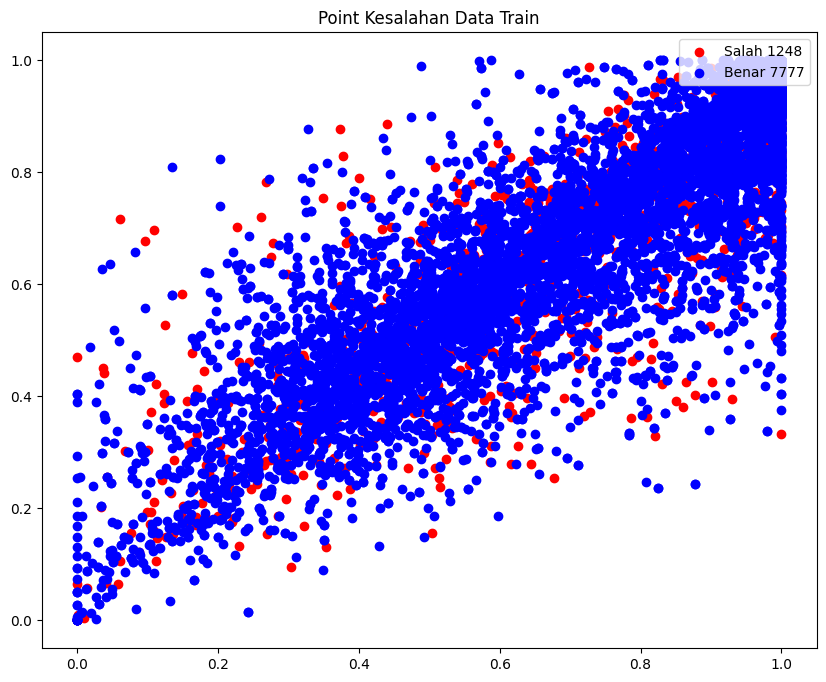

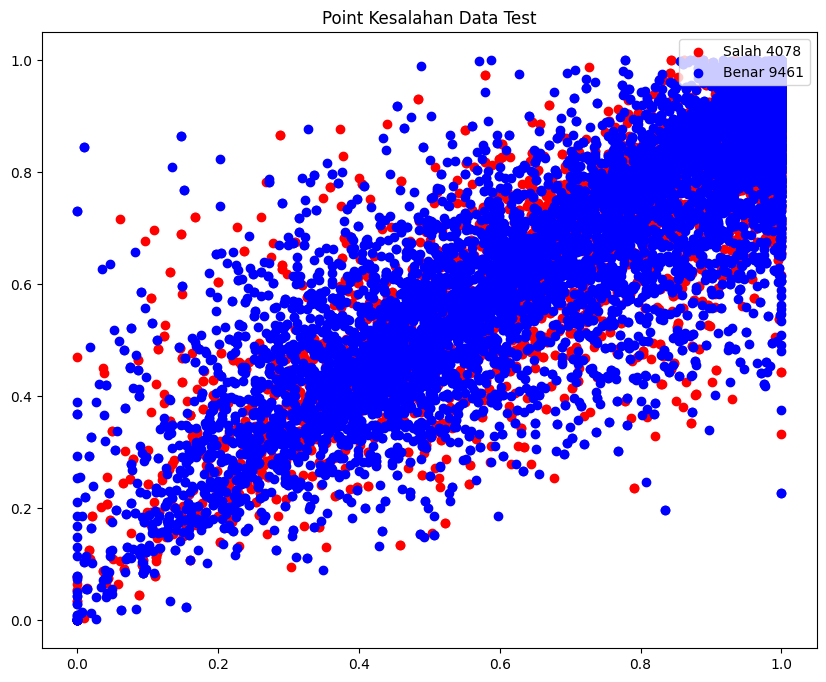

In [426]:
incorrect_point(y_train, y_pred_train, X_train.values)
incorrect_point(y_test, y_pred_test, X_test.values, title='Test')